In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
from sklearn.datasets import load_diabetes

In [ ]:
diabetes = load_diabetes(as_frame=True)

In [ ]:
X = diabetes.data
y = diabetes.target

In [ ]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
y.head()

,target
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


In [ ]:
y.mean(), y.median()

(np.float64(152.13348416289594), 140.5)

In [ ]:
X.shape, y.shape

((442, 10), (442,))

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = MinMaxScaler()

X_train_normal = scaler.fit_transform(X_train)
X_test_normal = scaler.transform(X_test)

In [ ]:
tf.random.set_seed(42)

diabetes_model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
diabetes_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)
history = diabetes_model.fit(
    X_train_normal, y_train,
    epochs=100,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 153.7891 - mae: 153.7891
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 152.6879 - mae: 152.6879
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 151.3234 - mae: 151.3234 
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 149.3647 - mae: 149.3647 
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 146.4388 - mae: 146.4388 
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 142.2271 - mae: 142.2271 
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 136.4769 - mae: 136.4769 
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 128.8997 - mae: 128.8997 
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 119.1946 - mae: 119.1946 
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 107.2203 - mae: 107.2203 
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 94.1783 - mae: 94.1783
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 81.787

In [ ]:
diabetes_model.evaluate(X_test_normal, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 43.3850 - mae: 43.3850 


[43.38500213623047, 43.38500213623047]

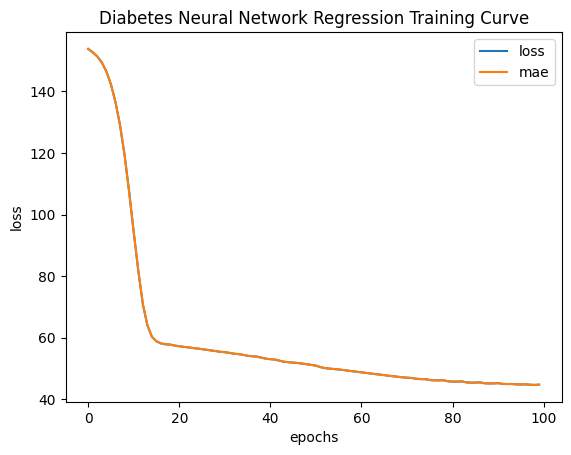

In [ ]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title("Diabetes Neural Network Regression Training Curve")
plt.show()

In [ ]:
y_preds = diabetes_model.predict(X_test_normal)

comparison_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_preds.squeeze()
})

comparison_df.head(10)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


,y_true,y_pred
0,219.0,152.820984
1,70.0,167.357513
2,202.0,142.604553
3,230.0,290.477112
4,111.0,124.284622
5,84.0,108.384476
6,242.0,216.741486
7,272.0,189.561401
8,94.0,84.142891
9,96.0,104.669701


In [ ]:
def evaluate_model(model, history, X_test, y_test, model_name):
  test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

  result = {
      "model": model_name,
      "train mae": history.history["mae"][-1],
      "validation mae":history.history["val_mae"][-1],
      "test mae": test_mae
  }

  return result

In [ ]:
tf.random.set_seed(42)

diabetes_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])
diabetes_model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)
history_2 = diabetes_model_2.fit(
    X_train_normal,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1,
)
result_list = []
result_list.append(
    evaluate_model(
        diabetes_model_2,
        history_2,
        X_test_normal,
        y_test,
        "diabetes_model_2"
    )
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 158.3569 - mae: 158.3569 - val_loss: 133.5776 - val_mae: 133.5776
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 157.8539 - mae: 157.8539 - val_loss: 132.9993 - val_mae: 132.9993
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 157.1486 - mae: 157.1486 - val_loss: 132.2209 - val_mae: 132.2209
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 156.2402 - mae: 156.2402 - val_loss: 131.2310 - val_mae: 131.2310
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 155.0725 - mae: 155.0725 - val_loss: 129.9413 - val_mae: 129.9413
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 153.5530 - mae: 153.5530 - val_loss: 128.2733 - val_mae: 128.2733
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 151.6096 - mae: 151.6096 - val_loss: 126.1608 - val_mae: 126.1608
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 149.1777 - mae: 149.1777 - val_loss: 123.5484 - val_mae: 123.5484
Epoch 9/100
9/9

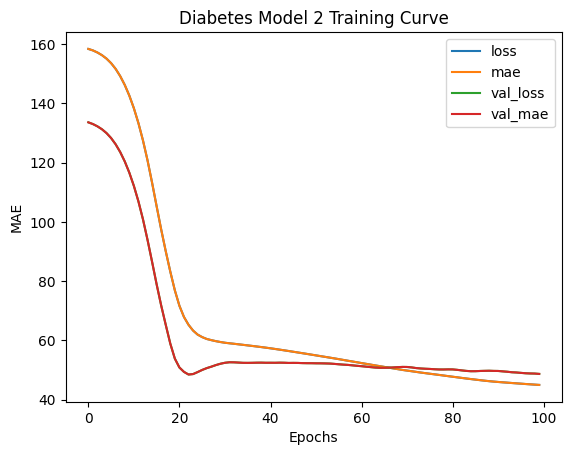

In [ ]:
pd.DataFrame(history_2.history).plot()
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Diabetes Model 2 Training Curve")
plt.show()

In [ ]:
model_2_loss, model_2_mae = diabetes_model_2.evaluate(X_test_normal, y_test)

print(f"Model 2 Loss: {model_2_loss}")
print(f"Model 2 MAE: {model_2_mae}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 43.8501 - mae: 43.8501
Model 2 Loss: 43.85007095336914
Model 2 MAE: 43.85007095336914


Activation eklemek modeli daha esnek hale getirir.  
Ama küçük datasetlerde daha esnek model her zaman daha iyi genelleme yapmaz.  

Model 2, ikinci hidden layer’a ReLU ekleyerek non-linear kapasiteyi artırdı.  
Training curve sağlıklı ilerledi ve overfitting belirgin görünmedi.  
Ancak test MAE baseline modele göre belirgin şekilde iyileşmedi.  
Bu yüzden bu değişiklik öğrenme sürecini bozmadı ama bu dataset için güçlü bir performans artışı da sağlamadı.  

In [ ]:
tf.random.set_seed(42)

diabetes_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])
diabetes_model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)
history_3 = diabetes_model_3.fit(
    X_train_normal,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1,
)
result_list.append(
    evaluate_model(
        diabetes_model_3,
        history_3,
        X_test_normal,
        y_test,
        "diabetes_model_3"
    )
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 158.6913 - mae: 158.6913 - val_loss: 134.0388 - val_mae: 134.0388
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 158.5437 - mae: 158.5437 - val_loss: 133.9135 - val_mae: 133.9135
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 158.4041 - mae: 158.4041 - val_loss: 133.7582 - val_mae: 133.7582
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 158.2098 - mae: 158.2098 - val_loss: 133.5193 - val_mae: 133.5193
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 157.8954 - mae: 157.8954 - val_loss: 133.1330 - val_mae: 133.1330
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 157.4079 - mae: 157.4079 - val_loss: 132.5539 - val_mae: 132.5539
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 156.6785 - mae: 156.6785 - val_loss: 131.6839 - val_mae: 131.6839
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 155.5619 - mae: 155.5619 - val_loss: 130.3340 - val_mae: 130.3340
Epoch 9/100
9/9

In [ ]:
model_3_loss, model_3_mae = diabetes_model_3.evaluate(X_test_normal, y_test)

print(f"Model 3 Loss: {model_3_loss}")
print(f"Model 3 MAE: {model_3_mae}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 42.9546 - mae: 42.9546
Model 3 Loss: 42.95459747314453
Model 3 MAE: 42.95459747314453


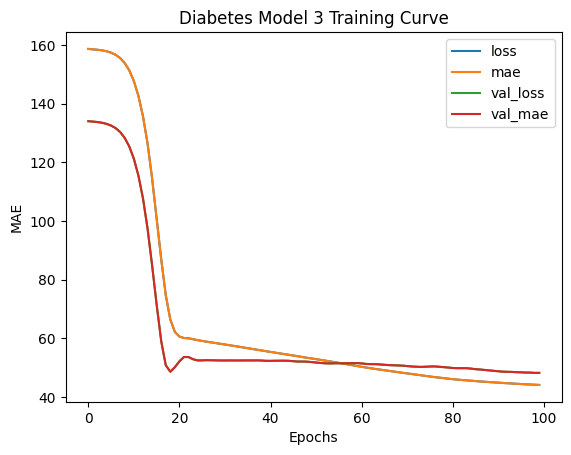

In [ ]:
pd.DataFrame(history_3.history).plot()
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.title("Diabetes Model 3 Training Curve")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_mae

64.00646146990485